In [1]:
#@title Autoload all necessary modules
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

%load_ext autoreload
%autoreload 2

import configargparse
import json
import sde_lib
import sampling
import util.utils as utils
from util.checkpoint import restore_checkpoint, save_checkpoint
from util import datasets
from models import ncsnpp
import models.utils as mutils
from models.ema import ExponentialMovingAverage
import torch
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import likelihood
import gc
%matplotlib inline


/disk/homeDIRS/rrajpal/miniconda3/lib/python3.13/site-packages/torch/utils/cpp_extension.py:2356: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/disk/homeDIRS/rrajpal/miniconda3/lib/python3.13/site-packages/torch/utils/cpp_extension.py:2356: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


In [2]:
#@title Setting up the configuration file

p = configargparse.ArgParser()
p.add('-cc', is_config_file=True, default='configs/default_cifar10.txt')
p.add('-sc', is_config_file=True, default='configs/specific_cifar10.txt')

p.add('--root', default='.')
p.add('--workdir', default='work_dir')
p.add('--eval_folder', default=None)
p.add('--mode', choices=['train', 'eval', 'continue'], default='eval')
p.add('--cont_nbr', type=int, default=None)
p.add('--checkpoint', default=None)

p.add('--n_gpus_per_node', type=int, default=1)
p.add('--n_nodes', type=int, default=1)
p.add('--node_rank', type=int, default=0)
p.add('--master_address', default='127.0.0.1')
p.add('--master_port', type=int, default=6020)
p.add('--distributed', action='store_false')

p.add('--overwrite', action='store_true')

p.add('--seed', type=int, default=0)

# Data
p.add('--dataset')
p.add('--is_image', action='store_true')
p.add('--image_size', type=int)
p.add('--center_image', action='store_true')
p.add('--image_channels', type=int)
p.add('--data_dim', type=int)  # Dimension of non-image data
p.add('--data_location', default=None)

# SDE
p.add('--sde')
p.add('--beta_type')
# Linear beta params
p.add('--beta0', type=float)
p.add('--beta1', type=float)
# ULD params
p.add('--m_inv', type=float)
p.add('--gamma', type=float)
p.add('--numerical_eps', type=float)

# Optimization
p.add('--optimizer')
p.add('--learning_rate', type=float)
p.add('--weight_decay', type=float)
p.add('--grad_clip', type=float)

# Objective
p.add('--cld_objective', choices=['dsm', 'hsm'], default='hsm')
p.add('--loss_eps', type=float)
p.add('--weighting', choices=['likelihood', 'reweightedv1', 'reweightedv2'])

# Model
p.add('--name')
p.add('--ema_rate', type=float)
p.add('--normalization')
p.add('--nonlinearity')
p.add('--n_channels', type=int)
p.add('--ch_mult')
p.add('--n_resblocks', type=int)
p.add('--attn_resolutions')
p.add('--resamp_with_conv', action='store_true')
p.add('--use_fir', action='store_true')
p.add('--fir_kernel')
p.add('--skip_rescale', action='store_true')
p.add('--resblock_type')
p.add('--progressive')
p.add('--progressive_input')
p.add('--progressive_combine')
p.add('--attention_type')
p.add('--init_scale', type=float)
p.add('--fourier_scale', type=int)
p.add('--conv_size', type=int)
p.add('--dropout', type=float)
p.add('--mixed_score', action='store_true')
p.add('--embedding_type', choices=['fourier', 'positional'])

# Training
p.add('--training_batch_size', type=int)
p.add('--testing_batch_size', type=int)
p.add('--sampling_batch_size', type=int)
p.add('--n_train_iters', type=int)
p.add('--n_warmup_iters', type=int)
p.add('--snapshot_freq', type=int)
p.add('--log_freq', type=int)
p.add('--eval_freq', type=int)
p.add('--likelihood_freq', type=int)
p.add('--fid_freq', type=int)
p.add('--eval_threshold', type=int, default=1)
p.add('--likelihood_threshold', type=int, default=1)
p.add('--snapshot_threshold', type=int, default=1)
p.add('--fid_threshold', type=int, default=1)
p.add('--fid_samples_training', type=int)
p.add('--n_eval_batches', type=int)
p.add('--n_likelihood_batches', type=int)
p.add('--autocast_train', action='store_true')
p.add('--save_freq', type=int, default=None)
p.add('--save_threshold', type=int, default=1)

# Sampling
p.add('--sampling_method', choices=['ode', 'em', 'sscs'], default='ode')
p.add('--sampling_solver', default='scipy_solver')
p.add('--sampling_solver_options', type=json.loads, default={'solver': 'RK45'})
p.add('--sampling_rtol', type=float, default=1e-5)
p.add('--sampling_atol', type=float, default=1e-5)
p.add('--sscs_num_stab', type=float, default=0.)
p.add('--denoising', action='store_true')
p.add('--n_discrete_steps', type=int)
p.add('--striding', choices=['linear', 'quadratic', 'logarithmic'], default='linear')
p.add('--sampling_eps', type=float)

# Likelihood
p.add('--likelihood_solver', default='scipy_solver')
p.add('--likelihood_solver_options', type=json.loads, default={'solver': 'RK45'})
p.add('--likelihood_rtol', type=float, default=1e-5)
p.add('--likelihood_atol', type=float, default=1e-5)
p.add('--likelihood_eps', type=float, default=1e-5)
p.add('--likelihood_hutchinson_type', choices=['gaussian', 'rademacher'], default='rademacher')

# Evaluation
p.add('--ckpt_file')
p.add('--eval_sample', action='store_true')
p.add('--autocast_eval', action='store_true')
p.add('--eval_loss', action='store_true')
p.add('--eval_fid', action='store_true')
p.add('--eval_likelihood', action='store_true')
p.add('--eval_fid_samples', type=int, default=50000)
p.add('--eval_jacobian_norm', action='store_true')
p.add('--eval_iw_likelihood', action='store_true')
p.add('--eval_density', action='store_true')
p.add('--eval_density_npts', type=int, default=101)
p.add('--eval_sample_hist', action='store_true')
p.add('--eval_hist_samples', type=int, default=100000)
p.add('--eval_loss_variance', action='store_true')
p.add('--eval_loss_variance_images', type=int, default=1)
p.add('--eval_sample_samples', type=int, default=1)

batch_size = 64 #@param {"type": "integer"}
config = p.parse_args(args=['--distributed',
                            '--training_batch_size', str(batch_size),
                            '--testing_batch_size', str(batch_size),
                            '--sampling_batch_size', str(batch_size)])

config.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
#@title Setting up visualization code
inverse_scaler = utils.get_data_inverse_scaler(config)

def plot_samples(x):
    nrow = int(np.sqrt(x.shape[0]))
    image_grid = make_grid(inverse_scaler(x).clamp(0., 1.), nrow)
    plt.axis('off')
    plt.imshow(image_grid.permute(1, 2, 0).cpu())

In [4]:
#@title Setting up CLD
beta_fn = utils.build_beta_fn(config)
beta_int_fn = utils.build_beta_int_fn(config)
sde = sde_lib.CLD(config, beta_fn, beta_int_fn)

In [5]:
#@title Setting up the score model
score_model = mutils.create_model(config).to(config.device)
score_model = torch.nn.DataParallel(score_model)
ema = ExponentialMovingAverage(score_model.parameters(), decay=config.ema_rate)

optim_params = score_model.parameters()
optimizer = utils.get_optimizer(config, optim_params)
state = dict(optimizer=optimizer, model=score_model, ema=ema, step=0)

CKPT_PATH = 'checkpoints/cifar10_800k.pth'
state = dict(optimizer=optimizer, model=score_model, ema=ema, step=0)
state = restore_checkpoint('checkpoints/cifar10_800k.pth', state, device=config.device)
ema.copy_to(score_model.parameters())
score_model.eval();

# Sampling

The `time_step_striding_type` parameter determines how we discretize the time domain in the numerical scheme: the `linear` type evaluates the model at equidistant time points, whereas the `quadratic` type evaluates the model (according to a quadratic time schedule) less often in the noise regime and more often towards the end of sampling (data regime). For more details, see Appendix E.2.3 of our paper.

# SDE

/disk/homeDIRS/rrajpal/GeneralizedLangevinDiffusion/CLD-SGM/models/ncsnpp.py:244: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(False):


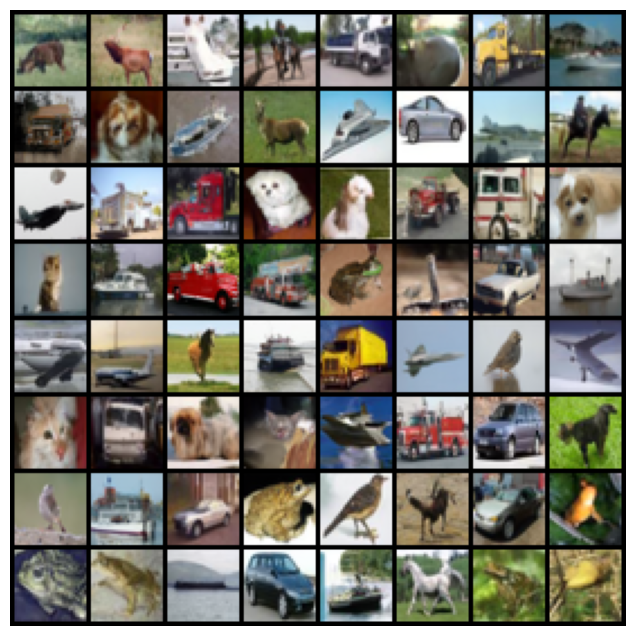

In [6]:
#@title SDE sampling
sampling_method = 'Symmetric Splitting CLD Sampler' #@param ['Symmetric Splitting CLD Sampler', 'Euler--Maruyama Sampler']

if sampling_method == 'Symmetric Splitting CLD Sampler':
  config.sampling_method = 'sscs'
elif sampling_method == 'Euler_Maruyama':
  config.sampling_method = 'em'
else:
  raise NotImplementedError

n_sampling_steps = 500 #@param {"type": "integer"}
config.n_discrete_steps = n_sampling_steps

time_step_striding_type = 'quadratic' #@param ['linear', 'quadratic']
config.striding = time_step_striding_type

config.sscs_num_stab = 1e-9

sampling_shape = (config.sampling_batch_size, 3, 32, 32)

sampler = sampling.get_sampling_fn(config, sde, sampling_shape, config.sampling_eps)
x, _, _ = sampler(score_model)

plt.figure(figsize=(8, 8))
plot_samples(x)

gc.collect()
if torch.cuda.is_available():
  torch.cuda.empty_cache()

# PFODE

/disk/homeDIRS/rrajpal/miniconda3/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `min_step`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
/disk/homeDIRS/rrajpal/GeneralizedLangevinDiffusion/CLD-SGM/models/ncsnpp.py:244: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(False):


Number of function evaluations: 327


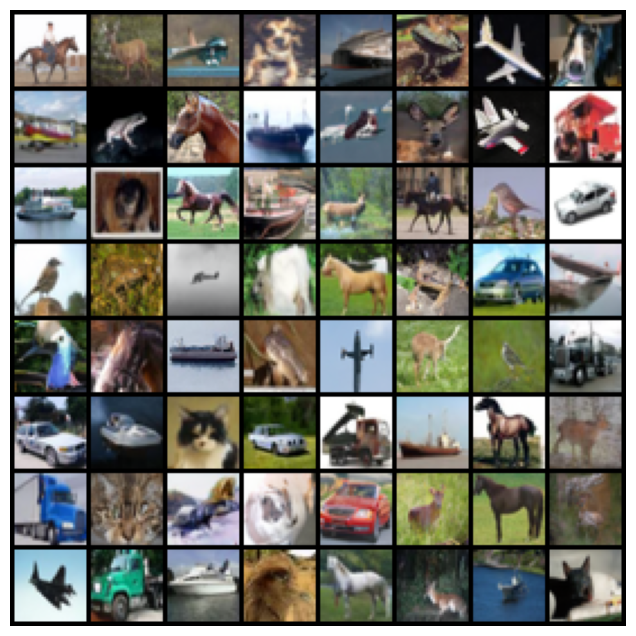

In [6]:
#@title ODE sampling
config.sampling_method = 'ode'
config.sampling_rtol = 1e-5
config.sampling_atol = 1e-5

sampling_shape = (config.sampling_batch_size, 3, 32, 32)

sampler = sampling.get_sampling_fn(config, sde, sampling_shape, config.sampling_eps)
x, _, nfe = sampler(score_model)
print('Number of function evaluations: %d' % nfe)

plt.figure(figsize=(8, 8))
plot_samples(x)

gc.collect()
if torch.cuda.is_available():
  torch.cuda.empty_cache()

# Likelihood computation

We can compute lower bounds on the log-likelihood of validation data for the ProbabilityFlow model.

In [ ]:
#@title ProbabilityFlow Likelihood
_, valid_queue, _ = datasets.get_loaders(config);

config.likelihood_rtol = 1e-5
config.likelihood_atol = 1e-5

likelihood_fn = likelihood.get_likelihood_fn(config, sde)
scaler = utils.get_data_scaler(config)

eval_batch_x = next(iter(valid_queue))[0]
eval_batch_x = (torch.rand_like(eval_batch_x) + eval_batch_x * 255.) / 256.

eval_batch_x = scaler(eval_batch_x).cuda()
eval_batch_z = torch.randn_like(eval_batch_x).cuda() * np.sqrt(sde.gamma / sde.m_inv)
eval_batch = torch.cat((eval_batch_x, eval_batch_z), dim=1)

nll, latent_u, nfe = likelihood_fn(state['model'], eval_batch)
shape = eval_batch_z.shape
nll -= 0.5 * np.prod(shape[1:]) * (1. + np.log(2. * np.pi) + np.log(sde.gamma / sde.m_inv))
bpd = utils.compute_bpd_from_nll(nll, np.prod(eval_batch_x.shape[1:]), inverse_scaler).detach().cpu().numpy().reshape(-1)

print('Mean negative log-likelihood bound (in BPD): %.3f' % np.mean(np.asarray(bpd)))

gc.collect()
if torch.cuda.is_available():
  torch.cuda.empty_cache()

Files already downloaded and verified
Files already downloaded and verified
Mean negative log-likelihood bound (in BPD): 3.269
